In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [105]:
df = pd.read_csv("/content/drive/MyDrive/AI ML Projects/ATM_cash_demand/atm_cash_management_dataset.csv")
df

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,ATM_0029,2022-07-02,Saturday,Night,32027,3097,Standalone,0,0,96493,Clear,2,35148
5654,ATM_0050,2023-12-08,Friday,Afternoon,60120,4948,Mall,0,0,128933,Rainy,5,51927
5655,ATM_0036,2022-10-04,Tuesday,Evening,32551,10819,Mall,0,0,104519,Snowy,3,31127
5656,ATM_0010,2022-04-19,Tuesday,Night,52965,13372,Gas Station,0,0,107829,Rainy,2,35886


In [106]:
df.head()

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784


In [107]:
df.shape

(5658, 13)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5658 entries, 0 to 5657
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ATM_ID                   5658 non-null   object
 1   Date                     5658 non-null   object
 2   Day_of_Week              5658 non-null   object
 3   Time_of_Day              5658 non-null   object
 4   Total_Withdrawals        5658 non-null   int64 
 5   Total_Deposits           5658 non-null   int64 
 6   Location_Type            5658 non-null   object
 7   Holiday_Flag             5658 non-null   int64 
 8   Special_Event_Flag       5658 non-null   int64 
 9   Previous_Day_Cash_Level  5658 non-null   int64 
 10  Weather_Condition        5658 non-null   object
 11  Nearby_Competitor_ATMs   5658 non-null   int64 
 12  Cash_Demand_Next_Day     5658 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 574.8+ KB


In [109]:
df.describe()

,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
count,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000,5658.000000
mean,49808.106928,10129.078473,0.022093,0.096501,100283.994698,2.477731,43085.207494
std,14903.539241,4878.853583,0.146998,0.295303,20122.365608,1.719487,16797.100086
min,1380.000000,0.000000,0.000000,0.000000,23266.000000,0.000000,0.000000
25%,39469.250000,6765.000000,0.000000,0.000000,86533.500000,1.000000,31558.750000
50%,50039.000000,10048.000000,0.000000,0.000000,100276.500000,2.000000,42589.500000
75%,60132.500000,13430.000000,0.000000,0.000000,113956.500000,4.000000,53831.000000
max,107790.000000,32395.000000,1.000000,1.000000,172227.000000,5.000000,114724.000000


In [110]:
df.isnull().sum()

,0
ATM_ID,0
Date,0
Day_of_Week,0
Time_of_Day,0
Total_Withdrawals,0
Total_Deposits,0
Location_Type,0
Holiday_Flag,0
Special_Event_Flag,0
Previous_Day_Cash_Level,0


In [111]:
df.duplicated().sum()

np.int64(0)

Exploratory Data Analysis (EDA)**bold text**

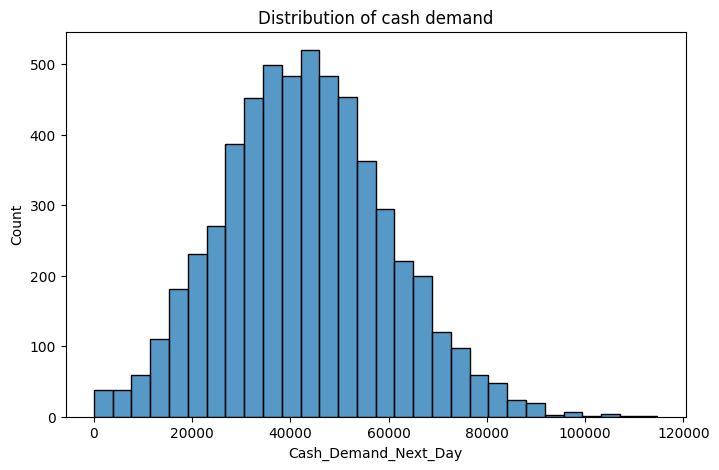

In [112]:
plt.figure(figsize=(8,5))
sns.histplot(df['Cash_Demand_Next_Day'], bins=30)
plt.title("Distribution of cash demand")
plt.show()

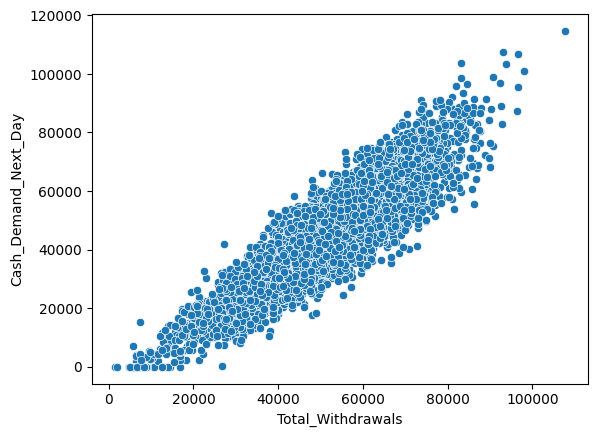

In [113]:
sns.scatterplot(
    x='Total_Withdrawals',
    y='Cash_Demand_Next_Day',
    data=df
)
plt.show()

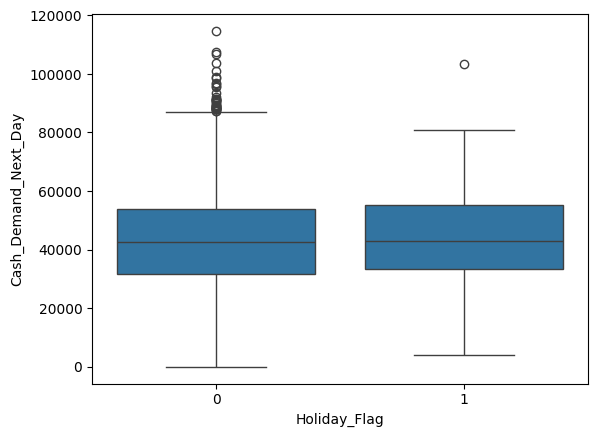

In [114]:
sns.boxplot(
    x='Holiday_Flag',
    y='Cash_Demand_Next_Day',
    data=df
)
plt.show()


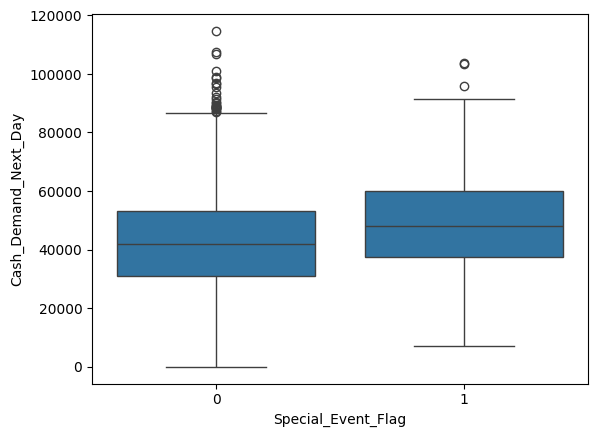

In [115]:
sns.boxplot(
    x='Special_Event_Flag',
    y='Cash_Demand_Next_Day',
    data=df
)
plt.show()

In [116]:
df.corr(numeric_only=True)

,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
Total_Withdrawals,1.000000,-0.000420,-0.028994,-0.004441,-0.009252,-0.012022,0.895053
Total_Deposits,-0.000420,1.000000,-0.000877,0.025669,-0.009107,0.006298,-0.213557
Holiday_Flag,-0.028994,-0.000877,1.000000,-0.008399,0.006642,-0.023580,0.019698
Special_Event_Flag,-0.004441,0.025669,-0.008399,1.000000,0.004580,0.001796,0.117524
Previous_Day_Cash_Level,-0.009252,-0.009107,0.006642,0.004580,1.000000,0.007805,-0.005849
Nearby_Competitor_ATMs,-0.012022,0.006298,-0.023580,0.001796,0.007805,1.000000,-0.014231
Cash_Demand_Next_Day,0.895053,-0.213557,0.019698,0.117524,-0.005849,-0.014231,1.000000


In [117]:
df['Date'] = pd.to_datetime(df['Date'])

In [118]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

In [119]:
df.head()

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day,Month,Day,Year
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165,4,25,2022
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249,11,24,2023
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901,8,27,2022
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155,8,27,2023
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784,12,15,2022


Label **Encoding**

In [145]:
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [121]:
categorical_cols = [
    'ATM_ID',
    'Day_of_Week',
    'Time_of_Day',
    'Location_Type',
    'Weather_Condition'
]
le=LabelEncoder()

for col in categorical_cols:
  df[col] = le.fit_transform(df[col])

In [122]:
df.head()

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day,Month,Day,Year
0,40,2022-04-25,1,2,57450,9308,3,0,0,112953,2,5,44165,4,25,2022
1,6,2023-11-24,0,2,72845,17896,4,0,0,115348,0,0,41249,11,24,2023
2,13,2022-08-27,2,2,42957,12712,4,0,0,90731,1,1,29901,8,27,2022
3,28,2023-08-27,3,1,43014,1375,2,0,0,88754,2,5,44155,8,27,2023
4,27,2022-12-15,4,1,36379,2938,0,0,0,129312,3,0,29784,12,15,2022


In [123]:
x = df.drop(
    ['Date', 'Cash_Demand_Next_Day'],
    axis=1
)
y = df['Cash_Demand_Next_Day']

**Target** **Variable** is Cash_Demand_Next_Day

Train-Test split

In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [166]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [167]:
models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

for name, pred in models.items():
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2:", r2_score(y_test, pred))


Linear Regression
MAE: 5034.950598895333
RMSE: 6095.934764185349
R2: 0.8711669901384568

Decision Tree
MAE: 7230.865724381625
RMSE: 9152.27049635859
R2: 0.7095949086136655

Random Forest
MAE: 5242.396024734983
RMSE: 6420.369167599092
R2: 0.8570887122554252

Gradient Boosting
MAE: 5034.667640056603
RMSE: 6132.862634565262
R2: 0.8696013766863501


In [168]:
final_model = lr

In [170]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": lr_pred
})

comparison.head(10)

,Actual,Predicted
3803,50335,44446.530949
5098,76882,71741.904630
3691,49730,43098.702119
1499,26431,30073.725391
3296,26694,25149.872254
1894,46721,57148.355855
1032,33525,31026.694229
4319,55148,53338.661553
4509,46102,36862.369535
1669,34770,39078.555678


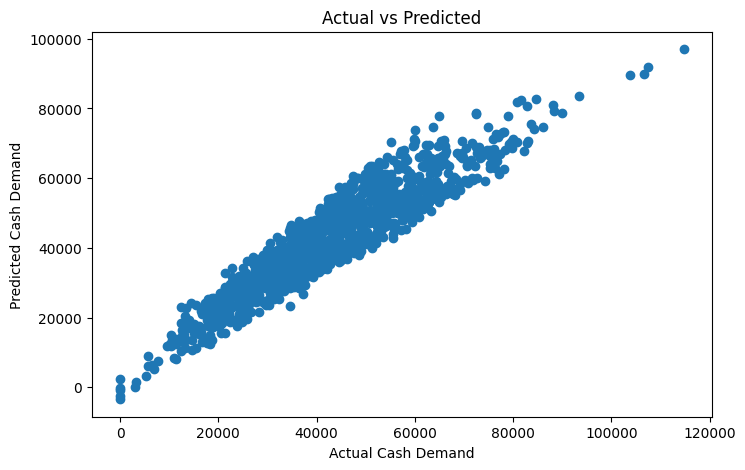

In [171]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Cash Demand")
plt.ylabel("Predicted Cash Demand")
plt.title("Actual vs Predicted")

plt.show()

In [172]:
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
7,Special_Event_Flag,7361.923598
6,Holiday_Flag,5492.495202
9,Weather_Condition,136.253468
11,Month,6.251621
5,Location_Type,5.958777
3,Total_Withdrawals,1.006063
8,Previous_Day_Cash_Level,-0.004152
4,Total_Deposits,-0.749597
0,ATM_ID,-2.855712
12,Day,-12.467068


In [175]:
import pickle

pickle.dump(
    lr,
    open('atm_cash_predictor.pkl', 'wb')
)

In [176]:
loaded_model = pickle.load(
    open('atm_cash_predictor.pkl', 'rb')
)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction[0])
print("Actual:", y_test.iloc[0])

Prediction: 44446.5309494978
Actual: 50335
